In [129]:
!pip install feature_engine

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from feature_engine.outliers import Winsorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

In [82]:
df = pd.read_csv("car_prices.csv")
df.shape

(558837, 16)

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558833 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 132.9 MB


In [84]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [85]:
df.describe(include = "str")

,make,model,trim,body,transmission,vin,state,color,interior,seller,saledate
count,548536,548438,548186,545642,493485,558833,558837,558088,558088,558837,558825
unique,96,973,1963,87,4,550297,64,46,17,14263,3766
top,Ford,Altima,Base,Sedan,automatic,automatic,fl,black,black,nissan-infiniti lt,Tue Feb 10 2015 01:30:00 GMT-0800 (PST)
freq,93554,19349,55817,199437,475915,22,82945,110970,244329,19693,5334


In [86]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [87]:
df.isnull().sum()/len(df)*100

year             0.000000
make             1.843292
model            1.860829
trim             1.905922
body             2.361154
transmission    11.694287
vin              0.000716
state            0.000000
condition        2.115107
odometer         0.016821
color            0.134028
interior         0.134028
seller           0.000000
mmr              0.006800
sellingprice     0.002147
saledate         0.002147
dtype: float64

## conclusion
- null values for every column is <30%
- fill values instead of removing

In [88]:
df["state"].value_counts()

state
fl                   82945
ca                   73148
pa                   53907
tx                   45913
ga                   34750
                     ...  
3vwd17aj4fm236636        1
3vwd17aj5fm225953        1
3vwd17aj7fm326640        1
3vwd17aj8fm239622        1
3vwd17aj2fm261566        1
Name: count, Length: 64, dtype: int64

## observation
- can se some vin numbers(car numbeers) in state column 

In [89]:
df[df["state"].str.len() > 2][["year","make","model","trim","body","transmission","vin","state","condition","odometer","color","interior","seller","mmr","sellingprice","saledate"]]

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
408161,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj4fm201708,NaN,46.0,4802,silver,gray,NaN,13200.0,16500
417835,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj2fm258506,NaN,1.0,9410,white,gray,NaN,13300.0,10500
421289,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj3fm276741,NaN,46.0,1167,blue,black,NaN,13200.0,12700
424161,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj2fm285365,NaN,1.0,2172,gray,black,NaN,14050.0,8250
427040,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj0fm227318,NaN,41.0,14872,gray,black,NaN,13700.0,14300
427043,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj6fm218641,NaN,49.0,12655,red,black,NaN,13850.0,14500
434424,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj7fm223475,NaN,46.0,15719,blue,black,NaN,13650.0,13500
444501,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj5fm297123,NaN,2.0,6388,white,black,NaN,13850.0,10700
453794,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj5fm219943,NaN,44.0,16633,silver,black,NaN,13600.0,13600
461597,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj9fm219766,NaN,44.0,11034,black,black,NaN,13900.0,13000


## observation
- you can see the columns from body shifted right
- year , make , model , trim values are correct
-  body values seems to be trim type values
-  body moved to transmission ,transmission values moved to cin and so on till saledate
-  the saledate coloumn values are lost
-  need to shift it right

## checking that bad data

In [90]:
df.loc[408161]

year                              2015
make                        Volkswagen
model                            Jetta
trim            SE PZEV w/Connectivity
body                       Navitgation
transmission                     Sedan
vin                          automatic
state                3vwd17aj4fm201708
condition                          NaN
odometer                          46.0
color                             4802
interior                        silver
seller                            gray
mmr                                NaN
sellingprice                   13200.0
saledate                         16500
Name: 408161, dtype: object

In [91]:
df.loc[408161].to_list()

[np.int64(2015),
 'Volkswagen',
 'Jetta',
 'SE PZEV w/Connectivity',
 'Navitgation',
 'Sedan',
 'automatic',
 '3vwd17aj4fm201708',
 np.float64(nan),
 np.float64(46.0),
 '4802',
 'silver',
 'gray',
 np.float64(nan),
 np.float64(13200.0),
 '16500']

In [92]:
df.columns.to_list()

['year',
 'make',
 'model',
 'trim',
 'body',
 'transmission',
 'vin',
 'state',
 'condition',
 'odometer',
 'color',
 'interior',
 'seller',
 'mmr',
 'sellingprice',
 'saledate']

In [93]:
df.shape

(558837, 16)

In [94]:
df[df["state"].str.len() > 2].shape

(26, 16)

In [95]:
df[df["state"].str.len() > 2]["make"].value_counts()

make
Volkswagen    26
Name: count, dtype: int64

In [96]:
df[df["state"].str.len() > 2]["model"].value_counts()

model
Jetta    26
Name: count, dtype: int64

## shifting values to right

In [97]:
df = pd.read_csv("car_prices.csv")

In [98]:
bad_state = df["state"].str.len() > 2
for idx in df.index[bad_state]:

    # Get the original values from body -> saledate
    row = df.loc[idx, [
        "body", "transmission", "vin", "state",
        "condition", "odometer", "color", "interior",
        "seller", "mmr", "sellingprice", "saledate"
    ]].tolist()

    # Shift one position to the left
    row = row[1:] + [np.nan]

    # Assign individually
    df.at[idx, "body"] = row[0]
    df.at[idx, "transmission"] = row[1]
    df.at[idx, "vin"] = row[2]
    df.at[idx, "state"] = row[3]
    df.at[idx, "condition"] = pd.to_numeric(row[4], errors="coerce")
    df.at[idx, "odometer"] = pd.to_numeric(row[5], errors="coerce")
    df.at[idx, "color"] = row[6]
    df.at[idx, "interior"] = row[7]
    df.at[idx, "seller"] = row[8]
    df.at[idx, "mmr"] = pd.to_numeric(row[9], errors="coerce")
    df.at[idx, "sellingprice"] = pd.to_numeric(row[10], errors="coerce")
    df.at[idx, "saledate"] = row[11]

In [99]:
df.loc[408161]

year                              2015
make                        Volkswagen
model                            Jetta
trim            SE PZEV w/Connectivity
body                             Sedan
transmission                 automatic
vin                  3vwd17aj4fm201708
state                              NaN
condition                         46.0
odometer                        4802.0
color                           silver
interior                          gray
seller                             NaN
mmr                            13200.0
sellingprice                   16500.0
saledate                           NaN
Name: 408161, dtype: object

In [100]:
df.dtypes

year              int64
make                str
model               str
trim                str
body                str
transmission        str
vin                 str
state               str
condition       float64
odometer        float64
color               str
interior            str
seller              str
mmr             float64
sellingprice    float64
saledate            str
dtype: object

In [101]:
df.drop("saledate", axis=1, inplace=True)

In [102]:
df.drop("vin",axis = 1,inplace = True)

## continue eda 

In [103]:
df.state.value_counts()

state
fl    82945
ca    73148
pa    53907
tx    45913
ga    34750
nj    27784
il    23486
nc    21845
oh    21575
tn    20895
mo    16013
mi    15511
nv    12685
va    12027
md    11158
wi     9851
mn     9429
az     8741
co     7775
wa     7416
ma     6729
ny     5699
in     4325
sc     4251
ne     4013
on     3442
pr     2725
la     2191
ms     1851
ut     1836
qc     1245
hi     1237
or     1155
ab      928
nm      171
ok       72
ns       61
al       26
Name: count, dtype: int64

In [104]:
a = df.describe()

a.columns

Index(['year', 'condition', 'odometer', 'mmr', 'sellingprice'], dtype='str')

In [105]:
b = df.describe(include="str")

b.columns

Index(['make', 'model', 'trim', 'body', 'transmission', 'state', 'color',
       'interior', 'seller'],
      dtype='str')

In [106]:
df["make"] = df["make"].fillna("Ford")
df["model"] = df["model"].fillna("Altima")
df["trim"] = df["trim"].fillna("Base")
df["body"] = df["body"].fillna("Sedan")
df["transmission"] = df["transmission"].fillna("automatic")
df["state"] = df["state"].fillna("fl")
df["color"] = df["color"].fillna("black")
df["interior"] = df["interior"].fillna("black")
df["condition"] = df["condition"].fillna(35.0)
df["odometer"] = df["odometer"].fillna(68320.0)
df["mmr"] = df["mmr"].fillna(13769.3)
df["sellingprice"] = df["sellingprice"].fillna(13611.3)

In [107]:
df.isnull().sum()

year             0
make             0
model            0
trim             0
body             0
transmission     0
state            0
condition        0
odometer         0
color            0
interior         0
seller          26
mmr              0
sellingprice     0
dtype: int64

- I would not replace them with a seller name because we don't know who the seller actually was.
- let that nan be same don't replace
- in ml we can encode that nan with "unkowm" category

In [108]:
df.dtypes

year              int64
make                str
model               str
trim                str
body                str
transmission        str
state               str
condition       float64
odometer        float64
color               str
interior            str
seller              str
mmr             float64
sellingprice    float64
dtype: object

<Axes: xlabel='sellingprice', ylabel='Count'>

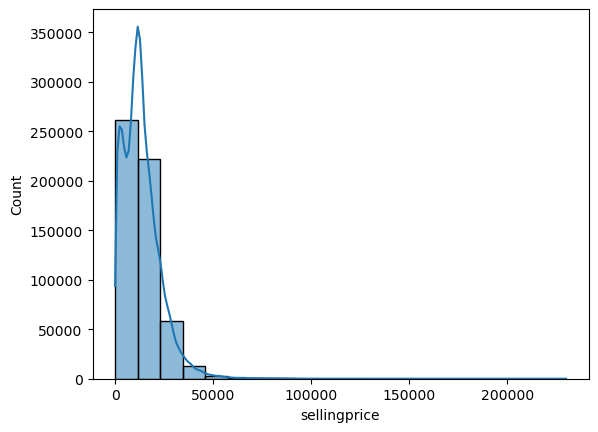

In [109]:
sns.histplot(x="sellingprice", data=df, kde=True, bins=20)

<Axes: xlabel='sellingprice'>

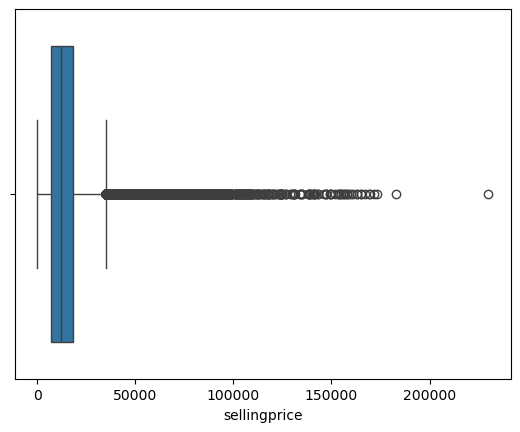

In [110]:
sns.boxplot(x="sellingprice",data= df)


In [111]:
df["sellingprice"].skew()

np.float64(1.953473198025756)

## observation
- all the columns if we check are strongly skewed and more outliers(here may be for high price cars possible)
- not handling outliers is good here:
- 1.outlier trimmer----> data will be lost
- 2.winsorizarion --------> may show same price for two diffrent range of cars
- should handle skewness by log tranformation

<Axes: xlabel='condition', ylabel='Count'>

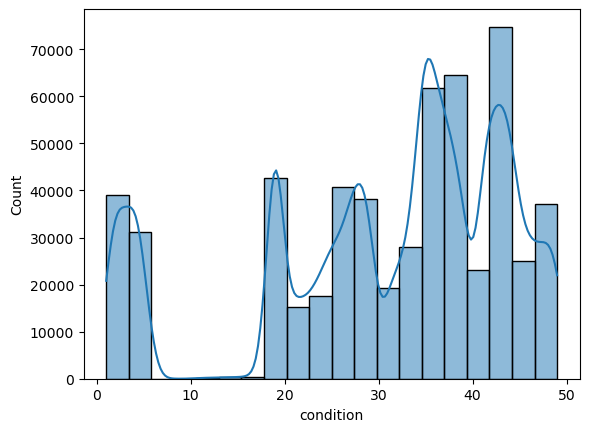

In [112]:
sns.histplot(x="condition", data=df, kde=True, bins=20)

<Axes: xlabel='condition'>

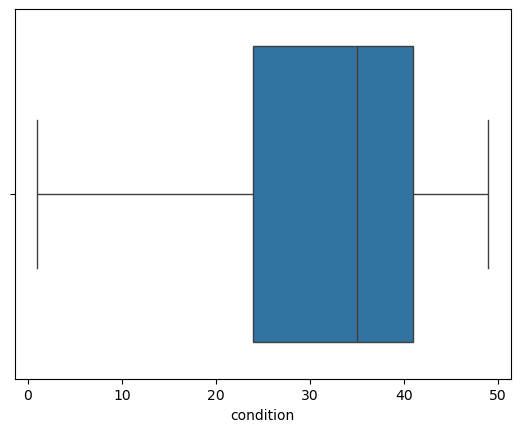

In [113]:
sns.boxplot(x="condition",data=df)

<Axes: xlabel='odometer', ylabel='Count'>

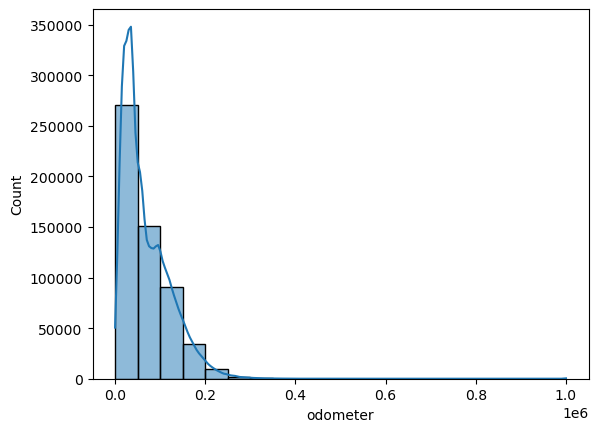

In [114]:
sns.histplot(x="odometer", data=df, kde=True, bins=20)

<Axes: xlabel='odometer'>

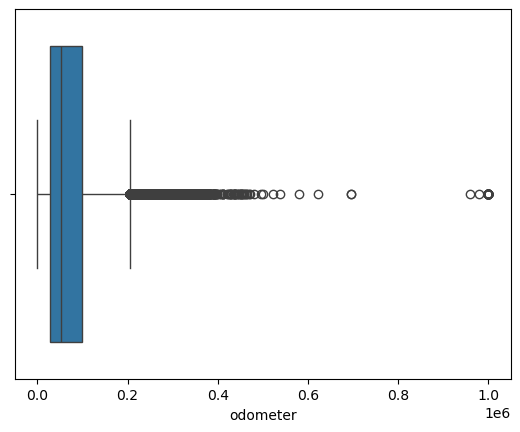

In [115]:
sns.boxplot(x="odometer",data=df)

<Axes: xlabel='mmr', ylabel='Count'>

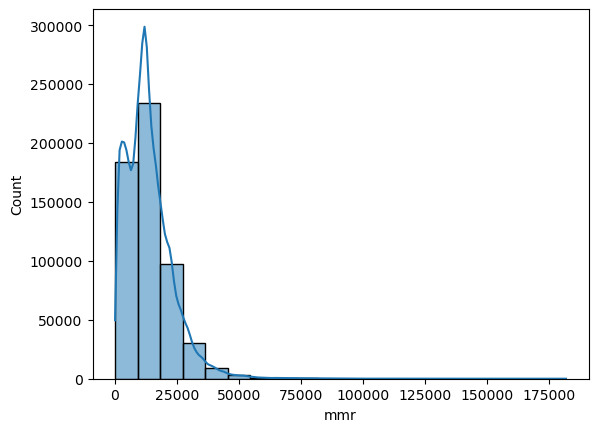

In [116]:
sns.histplot(x="mmr", data=df, kde=True, bins=20)

<Axes: xlabel='mmr'>

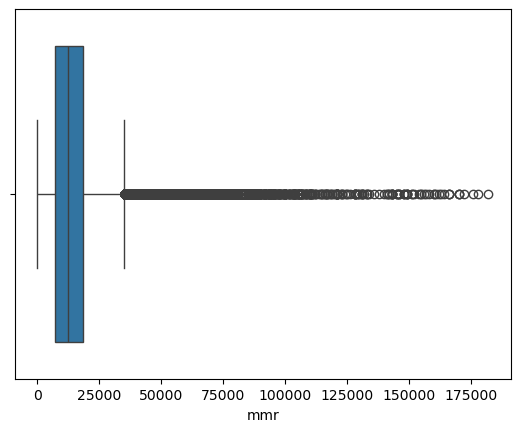

In [117]:
sns.boxplot(x="mmr",data = df)

In [119]:
df["sellingprice"] = np.log10(df["sellingprice"])
df["mmr"] = np.log10(df["mmr"])

In [124]:
df.odometer.skew()

np.float64(1.8434129571632223)

In [80]:
df = pd.read_csv("car_prices.csv")

In [122]:
df.odometer.head()

0    16639.0
1     9393.0
2     1331.0
3    14282.0
4     2641.0
Name: odometer, dtype: float64

<Axes: xlabel='mmr', ylabel='Count'>

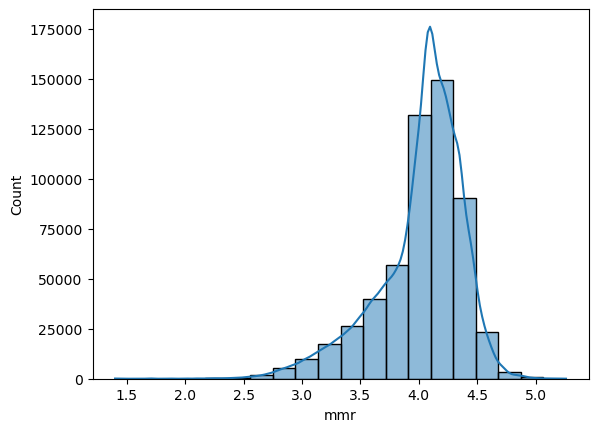

In [125]:
sns.histplot(x="mmr", data=df, kde=True, bins=20)

## encoding
- can't use one hot encoding cause we have lots of columns
- should not use label encoding cause it relates the values
- can use catboostregressor but this is an algorithm of ml cause we can use it later
- for now we can use label encoding

In [131]:
le = LabelEncoder()
df["make"] = le.fit_transform(df["make"])
df["model"] = le.fit_transform(df["model"])
df["trim"] = le.fit_transform(df["trim"])
df["body"] = le.fit_transform(df["body"])
df["transmission"] = le.fit_transform(df["transmission"])
df["state"] = le.fit_transform(df["state"])
df["color"] = le.fit_transform(df["color"])
df["interior"] = le.fit_transform(df["interior"])
df["seller"] = le.fit_transform(df["seller"])

## train_test_split


In [134]:
x=df.drop(["sellingprice"],axis = 1)
y=df["sellingprice"]

In [135]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=23)

## feature engineering

In [136]:
scaler = StandardScaler()

In [138]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## linear regression

In [140]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [142]:
y_pred = lin_reg.predict(x_test)

In [143]:
y_pred

array([4.48028834, 4.35034484, 4.08991072, ..., 4.25249898, 4.52368701,
       4.6022049 ], shape=(167652,))

In [148]:
y_test

441748    4.451018
209334    4.380211
538164    4.079181
226209    4.285557
374385    4.334454
            ...   
77239     3.963788
320568    3.690196
251357    4.222716
290951    4.541579
181680    4.618048
Name: sellingprice, Length: 167652, dtype: float64

In [144]:
mean_squared_error(y_pred, y_test)

0.011546271149207477

In [146]:
lin_reg.score(x_test, y_test)

0.9273784451809619

In [147]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.9273784451809619

## checking overfitting

In [150]:
scores = cross_val_score(lin_reg, x_train, y_train, cv = 5, scoring = 'r2')
scores

array([0.92675456, 0.92722208, 0.92877838, 0.9287289 , 0.92704789])

In [151]:
scores.mean()

np.float64(0.927706362394735)

- no overfitting cause the diffrence in training accuracy and cross_val_score accurecy is very less
- That's only about 0.03 percentage points